#  Enrutamiento con LLM Router Chain

## Importar librerías iniciales e instancia de modelo de chat

In [24]:
from langchain.prompts import PromptTemplate, SystemMessagePromptTemplate,ChatPromptTemplate, HumanMessagePromptTemplate
from langchain_openai import ChatOpenAI
from langchain.chains import SequentialChain, LLMChain #importamos el SequentialChain que es el modelo completo
f = open(r'C:\Users\joseantonio.clemente\Documents\Langchain\api_key.txt')
api_key = f.read()
llm = ChatOpenAI(openai_api_key=api_key)

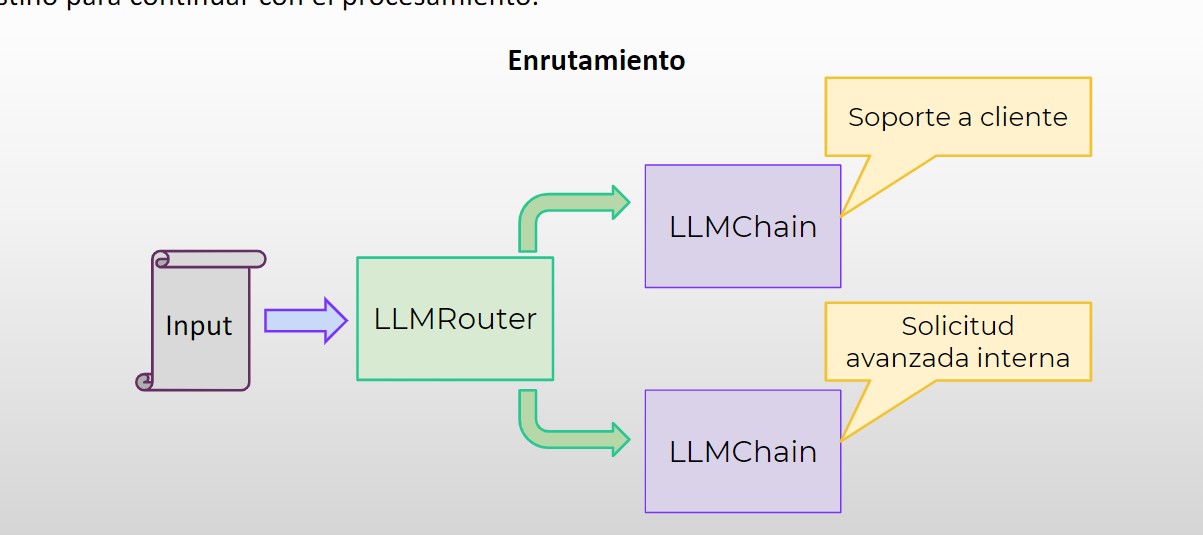

### Plantillas de enrutamiento

In [25]:
#Template (prompt) para soporte básico a clientes de coches
plantilla_soporte_basico_cliente = '''Eres una persona que asiste a los clientes de automóviles con preguntas básicas que pueden
necesitar en su día a día y que explica los conceptos de una manera que sea simple de entender. Asume que no tienen conocimiento
previo. Esta es la pregunta del usuario/n{input}'''

In [26]:
#Template (prompt) para soporte avanzados a nuestros expertos en mecánica
plantilla_soporte_avanzado_mecánico = '''Eres un experto en mecánica que explicas consultas avanzadas a los mecánicos
de la plantilla. Puedes asumir que cualquier que está preguntando tiene conocimientos avanzados de mecánica. 
Esta es la pregunta del usuario/n{input}'''

In [27]:
#Se pueden añadir todas las plantillas que necesitemos

### Prompts a enrutar

In [46]:
#Debemos crear una lista de diccionarios, cada diccionario contiene su nombre, la descripción (en base a la cual el enrutador
#hará su trabajo) y el prompt a usar en cada caso
prompt_infos = [
    {'name':'mecánica básica',
        'description': 'Responde preguntas básicas de mecánicas a clientes', #se basa en este campo para enrutar por un lado o por el otro
        'prompt_template':plantilla_soporte_basico_cliente},
    {'name':'mecánica avanzada',
        'description': 'Responde preguntas avanzadas de mecánica a expertos con conocimiento previo',
        'prompt_template':plantilla_soporte_avanzado_mecánico},
    
]

In [29]:
#TODO LO QUE VIENE A CONTINUACIÓN ES AGNÓSTICO DEL CASO DE USO Y LO PUEDES UTILIZAR PARA TODOS LOS CASOS DE USO

### ConversationChain

In [30]:
from langchain.chains import LLMChain

In [ ]:
#Creamos un diccionario de objetos LLMChain con las posibles cadenas destino. CREO QUE UNA SERIE DE CADENAS USANDO LOS DICCIONARIOS DE LOS PROMPTS ANTERIORES
destination_chains = {}
for p_info in prompt_infos:
    name = p_info["name"]
    prompt_template = p_info["prompt_template"]
    prompt = ChatPromptTemplate.from_template(template=prompt_template)
    chain = LLMChain(llm=llm, prompt=prompt)
    destination_chains[name] = chain

In [32]:
destination_chains

{'mecánica básica': LLMChain(verbose=False, prompt=ChatPromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['input'], input_types={}, partial_variables={}, template='Eres una persona que asiste a los clientes de automóviles con preguntas básicas que pueden\nnecesitar en su día a día y que explica los conceptos de una manera que sea simple de entender. Asume que no tienen conocimiento\nprevio. Esta es la pregunta del usuario/n{input}'), additional_kwargs={})]), llm=ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000221948C2B10>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000221938864E0>, root_client=<openai.OpenAI object at 0x00000221901AD730>, root_async_client=<openai.AsyncOpenAI object at 0x00000221948C3470>, model_kwargs={}, openai_api_key=SecretStr('**********')), output_parser=StrOutputPars

In [33]:
#Creamos el prompt y cadena por defecto puesto que son argumento obligatorios que usaremos posteriormente
default_prompt = ChatPromptTemplate.from_template("{input}")
default_chain = LLMChain(llm=llm,prompt=default_prompt)

### Multi Routing Template

In [34]:
#Importamos una plantilla que podremos formatear su parámetro {destinations} que tendrá cada nombre y descripción de la información de prompts
from langchain.chains.router.multi_prompt_prompt import MULTI_PROMPT_ROUTER_TEMPLATE

In [35]:
print(MULTI_PROMPT_ROUTER_TEMPLATE) #El parámetro importante es {destinations}, debemos formatearlo en tipo string

Given a raw text input to a language model select the model prompt best suited for the input. You will be given the names of the available prompts and a description of what the prompt is best suited for. You may also revise the original input if you think that revising it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{{{
    "destination": string \ name of the prompt to use or "DEFAULT"
    "next_inputs": string \ a potentially modified version of the original input
}}}}
```

REMEMBER: "destination" MUST be one of the candidate prompt names specified below OR it can be "DEFAULT" if the input is not well suited for any of the candidate prompts.
REMEMBER: "next_inputs" can just be the original input if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
{destinations}

<< INPUT >>
{{input}}

<< OUTPUT (must include ```json at the start of the respon

### Destinos de Routing

In [47]:
#Creamos una string global con todos los destinos de routing usando el nombre y descripción de "prompt_infos"
destinations = [f"{p['name']}: {p['description']}" for p in prompt_infos]
destinations_str = " \n ".join(destinations)

In [48]:
destinations_str

'mecánica básica: Responde preguntas básicas de mecánicas a clientes \n mecánica avanzada: Responde preguntas avanzadas de mecánica a expertos con conocimiento previo'

### Router Prompt

In [38]:
from langchain.chains.router.llm_router import LLMRouterChain,RouterOutputParser

In [49]:
router_template = MULTI_PROMPT_ROUTER_TEMPLATE.format(
    destinations=destinations_str #Formateamos la plantilla con nuestros destinos en la string destinations_str
)
router_prompt = PromptTemplate(
    template=router_template,
    input_variables=["input"],
    output_parser=RouterOutputParser(), #Para transformar el objeto JSON parseándolo a una string
)

In [50]:
print(router_template) #verificamos que se ha formateado correctamente

Given a raw text input to a language model select the model prompt best suited for the input. You will be given the names of the available prompts and a description of what the prompt is best suited for. You may also revise the original input if you think that revising it will ultimately lead to a better response from the language model.

<< FORMATTING >>
Return a markdown code snippet with a JSON object formatted to look like:
```json
{{
    "destination": string \ name of the prompt to use or "DEFAULT"
    "next_inputs": string \ a potentially modified version of the original input
}}
```

REMEMBER: "destination" MUST be one of the candidate prompt names specified below OR it can be "DEFAULT" if the input is not well suited for any of the candidate prompts.
REMEMBER: "next_inputs" can just be the original input if you don't think any modifications are needed.

<< CANDIDATE PROMPTS >>
mecánica básica: Responde preguntas básicas de mecánicas a clientes 
 mecánica avanzada: Responde pre

### Routing Chain Call

In [41]:
from langchain.chains.router import MultiPromptChain

In [42]:
router_chain = LLMRouterChain.from_llm(llm, router_prompt)

In [43]:
chain = MultiPromptChain(router_chain=router_chain, 
                         destination_chains=destination_chains, #El objeto con los posibles LLMChain que creamos al inicio
                         default_chain=default_chain, verbose=True #Indicamos el LLMChain por defecto (obligatorio)
                        )

In [51]:
chain.invoke("¿Cómo cambio el aceite de mi coche?")



> Entering new MultiPromptChain chain...
mecánica básica: {'input': '¿Cómo cambio el aceite de mi coche?'}
> Finished chain.


{'input': '¿Cómo cambio el aceite de mi coche?',
 'text': 'Cambiar el aceite de tu coche es una tarea importante para mantenerlo en buen estado. Aquí te explico de manera sencilla cómo hacerlo:\n\n1. Primero, necesitarás levantar el coche con un gato hidráulico y asegurarlo con soportes para evitar accidentes.\n\n2. Ubica el tapón del cárter de aceite debajo del motor. Es importante tener listo un recipiente para recoger el aceite usado.\n\n3. Afloja el tapón con una llave adecuada y deja que el aceite viejo escurra completamente.\n\n4. Una vez haya salido todo el aceite, vuelve a colocar el tapón y asegúralo correctamente.\n\n5. Ahora, busca el filtro de aceite, que generalmente se ubica en la parte baja del motor. Afloja el filtro con una llave de filtro o una herramienta especial y cámbialo por uno nuevo.\n\n6. Antes de poner el aceite nuevo, revisa el manual del fabricante para saber cuántos litros necesitas y qué tipo de aceite es el adecuado para tu coche.\n\n7. Vierte el aceite 

In [52]:
chain.invoke("¿Cómo funciona internamente un catalizador?")



> Entering new MultiPromptChain chain...
mecánica avanzada: {'input': '¿Cómo funciona internamente un catalizador?'}
> Finished chain.


{'input': '¿Cómo funciona internamente un catalizador?',
 'text': 'El catalizador, que generalmente consta de un núcleo cerámico cubierto con metales preciosos como platino, paladio o rodio, funciona mediante una reacción química que convierte los gases tóxicos emitidos por el motor en gases menos dañinos para el medio ambiente.\n\nCuando los gases de escape entran en el catalizador, los hidrocarburos y monóxido de carbono se oxidan, mientras que los óxidos de nitrógeno se reducen a nitrógeno y oxígeno. Esto se logra gracias a las propiedades catalíticas de los metales preciosos presentes en el catalizador, que aceleran estas reacciones químicas sin ser consumidos en el proceso.\n\nEn resumen, el catalizador transforma los gases tóxicos en gases más seguros, contribuyendo a la reducción de la contaminación ambiental causada por los vehículos. Es importante mantener el catalizador en buen estado para que funcione correctamente y cumpla su función de manera efectiva.'}